# Staircase Shape Test -- generation only, no placement yet

Generator B (`layout_generation.ipynb`) currently gives a speculative farm its boundary by taking one of the 13 real lease polygons and rescaling it isotropically to the target area -- distorting a borrowed shape rather than generating one. This notebook tests generating the boundary natively on the regional grid instead, and went through two iterations before landing on something that actually matches the real data on more than one metric at once:

1. A random block-by-block growth (Eden growth / lattice-animal model) gets the area and the 0/90 alignment right, but comes out visibly too 'blobby' -- round, riddled with small concave fingers -- because that is what this kind of random growth process does at scale, not because real leases look that way.
2. Adding a direction bias fixes the roundness (aspect ratio) but not the fingering -- measured with a proper metric (solidity, below), it makes the fingering slightly worse.
3. Building a smooth, mostly-convex outline first (1-3 corner-overlapped rectangles) and rasterizing it onto the block grid afterwards fixes both at once: the zigzag only appears where the smooth edge crosses the grid, which is closer to what a real lease boundary plausibly goes through.

On purpose, shape only throughout -- no rotation search, no SLA/bathymetry/connection filtering, no overlap checking, no positioning relative to Vineyard Wind. Positioning stays in `layout_generation.ipynb`'s `generate_farm()`/`populate_scenario()` -- this notebook only replaces what feeds into it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import windIO
import yaml
from pathlib import Path
from shapely.geometry import Polygon

from staircase import (
    grow_staircase_boundary, grow_eden_boundary,
    solidity, bbox_aspect_ratio, staircase_run_lengths,
    CELL_AREA_KM2, DEFAULT_ELONGATION,
)

DATA_DIR = Path("..") / ".." / "Data"
SYSTEM_YAML = DATA_DIR / "site_us.yaml"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

RNG_SEED = 7
COLORS = {"Haliade-X 13MW": "#1B6E86", "Haliade-X 15.5MW": "#2E8CA6", "DTU10MW": "#C17A1F"}

## 1. The regional alignment, measured (not assumed)

For each of the 13 real lease boundaries in `site_us.yaml`, the length-weighted histogram of edge bearing (mod 90 deg) below shows how much of each perimeter sits within 2 deg of a cardinal direction. This is the same check already run on the 4 real turbine layouts (which came out ~0/90 deg too) -- here it is the boundaries themselves, all 13, including the ones that never got a turbine. `REGIONAL_THETA1` is set from this measurement, not assumed, and every shape generated below shares it -- no rotation is sampled per farm.

In [2]:
BOUNDARY_NAMES = [
    "Vineyard Wind", "Revolution Wind", "SouthCoast Wind", "South Fork Wind",
    "Sunrise Wind South", "Sunrise Wind North", "Revolution Wind North",
    "Vineyard Northeast", "New England Wind 1", "New England Wind 2 South",
    "Beacon Wind", "Bay State Wind South", "Bay State Wind North",
]

site_us = windIO.load_yaml(SYSTEM_YAML)
boundary_polygons = site_us["boundaries"]["polygons"]
LEASE_TEMPLATES = {name: Polygon(zip(p["x"], p["y"])) for name, p in zip(BOUNDARY_NAMES, boundary_polygons)}


def bearing_concentration(polygon, tol_deg=2.0):
    """Fraction of perimeter (length-weighted) within tol_deg of 0 or 90 deg."""
    x, y = np.array(polygon.exterior.coords.xy[0]), np.array(polygon.exterior.coords.xy[1])
    dx, dy = np.diff(x), np.diff(y)
    length = np.hypot(dx, dy)
    angle = np.degrees(np.arctan2(dy, dx)) % 90
    near_cardinal = (angle < tol_deg) | (angle > 90 - tol_deg)
    return length[near_cardinal].sum() / length.sum()


fracs = {name: bearing_concentration(poly) for name, poly in LEASE_TEMPLATES.items()}
for name, frac in fracs.items():
    print(f"{name:28s} {frac * 100:5.1f}% of perimeter within 2 deg of 0/90")
print(f"\nmean across all 13: {np.mean(list(fracs.values())) * 100:.1f}%")

REGIONAL_THETA1 = 0.0  # confirmed by the measurement above -- not assumed

Vineyard Wind                 99.6% of perimeter within 2 deg of 0/90
Revolution Wind              100.0% of perimeter within 2 deg of 0/90
SouthCoast Wind              100.0% of perimeter within 2 deg of 0/90
South Fork Wind              100.0% of perimeter within 2 deg of 0/90
Sunrise Wind South           100.0% of perimeter within 2 deg of 0/90
Sunrise Wind North           100.0% of perimeter within 2 deg of 0/90
Revolution Wind North        100.0% of perimeter within 2 deg of 0/90
Vineyard Northeast           100.0% of perimeter within 2 deg of 0/90
New England Wind 1           100.0% of perimeter within 2 deg of 0/90
New England Wind 2 South     100.0% of perimeter within 2 deg of 0/90
Beacon Wind                   99.8% of perimeter within 2 deg of 0/90
Bay State Wind South         100.0% of perimeter within 2 deg of 0/90
Bay State Wind North         100.0% of perimeter within 2 deg of 0/90

mean across all 13: 100.0%


## 2. The larger real leases, as a reference only -- not as pieces

Revolution Wind North (4.3 km2), Bay State Wind North (7.2 km2), and Sunrise Wind North (14.4 km2) are the same three leases small enough that `config.py` already treats them as negligible (`EXCLUDED_FARMS`) or barely fills them. Dropped from the reference set entirely -- the remaining 10 larger leases are used only to sanity-check the cell size and, in Section 3, the shape statistics -- not picked, scaled, or otherwise reused as a shape.

In [3]:
TINY_LEASES = {"Revolution Wind North", "Bay State Wind North", "Sunrise Wind North"}
LARGE_LEASES = {name: poly for name, poly in LEASE_TEMPLATES.items() if name not in TINY_LEASES}
large_areas_km2 = np.array([poly.area / 1e6 for poly in LARGE_LEASES.values()])

n_blocks = large_areas_km2 / CELL_AREA_KM2
residual = np.abs(n_blocks - np.round(n_blocks))
print(f"CELL_AREA_KM2 = {CELL_AREA_KM2:.2f} (= 1 nm^2)")
print(f"10 larger real leases -> implied block count and residual to nearest integer:")
for name_area, blocks, res in sorted(zip(large_areas_km2, n_blocks, residual)):
    print(f"  area={name_area:6.1f} km2  n_blocks~={blocks:6.1f}  residual={res:.2f}")
print(f"\nmean residual: {residual.mean():.2f} blocks (0 = perfect integer multiples)")

CELL_AREA_KM2 = 3.43 (= 1 nm^2)
10 larger real leases -> implied block count and residual to nearest integer:
  area=  55.5 km2  n_blocks~=  16.2  residual=0.17
  area= 197.9 km2  n_blocks~=  57.7  residual=0.31
  area= 212.5 km2  n_blocks~=  62.0  residual=0.03
  area= 264.2 km2  n_blocks~=  77.0  residual=0.04
  area= 334.5 km2  n_blocks~=  97.5  residual=0.47
  area= 430.9 km2  n_blocks~= 125.6  residual=0.36
  area= 515.6 km2  n_blocks~= 150.3  residual=0.34
  area= 521.2 km2  n_blocks~= 152.0  residual=0.03
  area= 535.7 km2  n_blocks~= 156.2  residual=0.17
  area= 579.2 km2  n_blocks~= 168.9  residual=0.13

mean residual: 0.21 blocks (0 = perfect integer multiples)


## 3. Solidity -- the metric that actually separates a jagged EDGE from a jagged BODY

A lease boundary can be irregular for two very different reasons: (a) a mostly-solid, near-rectangular shape whose edge just happens to cross the block grid at an angle -- a jagged *outline* around a solid body -- or (b) a shape with real concave notches, legs, and holes cut into the body itself. Bounding-box aspect ratio (used in Section 5 of the earlier pass on this notebook) cannot tell these apart. Solidity -- `area / convex-hull area`, 1.0 = perfectly convex -- can: it stays high for (a) and drops for (b), regardless of how jagged the edge itself looks.

Measured on the 10 larger real leases: mean 0.79-0.81, and the distribution is lopsided -- most (SouthCoast 0.87, South Fork 0.97, New England Wind 1 0.88, Beacon 0.87, Vineyard 0.86) sit at 0.82-0.98, essentially solid rectangles with a jagged edge. Only a few (Revolution Wind 0.60, Sunrise Wind South 0.70, New England Wind 2 South 0.67, Bay State Wind South 0.68) are genuinely notched, L/T-like shapes. That split -- mostly solid, occasionally notched -- is the actual thing to reproduce, not a uniformly 'somewhat jagged everywhere' body.

In [4]:
real_solidity = {name: solidity(poly) for name, poly in LARGE_LEASES.items()}
for name, s in sorted(real_solidity.items(), key=lambda kv: kv[1]):
    print(f"{name:28s} solidity={s:.3f}")
print(f"\nmean solidity, 10 larger real leases: {np.mean(list(real_solidity.values())):.3f}")

Revolution Wind              solidity=0.598
New England Wind 2 South     solidity=0.671
Bay State Wind South         solidity=0.679
Sunrise Wind South           solidity=0.697
Vineyard Northeast           solidity=0.819
Vineyard Wind                solidity=0.857
Beacon Wind                  solidity=0.872
SouthCoast Wind              solidity=0.873
New England Wind 1           solidity=0.881
South Fork Wind              solidity=0.975

mean solidity, 10 larger real leases: 0.792


## 3b. Run-length coherence -- a jagged edge that still traces ONE line

A shape can already be solid (Section 3) and still be locally incoherent -- little bumps that each point in an unrelated direction, instead of the staircase consistently drifting one way for a while before it genuinely turns a corner. Real leases do the latter: even where the edge zigzags, it keeps alternating between the *same pair* of compatible directions (e.g. only E/N) for many steps -- effectively a discretized single line -- before a real reversal happens. Measured as the number of consecutive boundary edges before that reversal (`staircase_run_lengths`): SouthCoast Wind mean 21.6 (max 55), Beacon Wind mean 23.4 (max 52), Vineyard Wind mean 12.2 (max 23) -- and Revolution Wind, the one real lease that already reads as more chaotic by eye, drops to mean 4.9. That range (about 5 to 23) is the target, not a single number.

In [5]:
for name, poly in sorted(LARGE_LEASES.items(), key=lambda kv: np.mean(staircase_run_lengths(kv[1]))):
    runs = staircase_run_lengths(poly)
    print(f"{name:28s} mean_run={np.mean(runs):5.2f}  max_run={max(runs):3d}  n_runs={len(runs):3d}")

South Fork Wind              mean_run= 3.00  max_run=  4  n_runs=  2
Revolution Wind              mean_run= 4.91  max_run= 19  n_runs= 11
Sunrise Wind South           mean_run= 5.00  max_run= 13  n_runs=  7
New England Wind 2 South     mean_run= 7.50  max_run= 20  n_runs=  8
New England Wind 1           mean_run= 7.71  max_run= 19  n_runs=  7
Vineyard Northeast           mean_run= 8.57  max_run= 33  n_runs=  7
Vineyard Wind                mean_run=12.20  max_run= 23  n_runs=  5
SouthCoast Wind              mean_run=21.60  max_run= 55  n_runs=  5
Beacon Wind                  mean_run=23.40  max_run= 52  n_runs=  5
Bay State Wind South         mean_run=30.33  max_run= 33  n_runs=  3


## 4. Twelve capacity draws, three methods

Same capacity distribution used elsewhere in this pipeline -- `REAL_FARM_SIZES_MW`, the 9 known real projects (`layout_generation.ipynb` Section 6) -- paired with a turbine model and a spacing in D, exactly as `build_scaled_farm` already does. `target_area_km2` follows from capacity and spacing exactly as before. What differs between the three blocks below is only which function turns that area into a boundary -- same 12 (capacity, turbine, spacing) draws, same per-draw shape-growth seed, so the comparison isolates the method, not the input.

In [6]:
def load_turbine(fname):
    with open(DATA_DIR / fname) as f:
        d = yaml.safe_load(f)
    return dict(diameter=d["rotor_diameter"], rated_mw=d["performance"]["rated_power"] / 1e6)

TURBINES = {
    "Haliade-X 13MW": load_turbine("haliadex_13mw.yaml"),
    "Haliade-X 15.5MW": load_turbine("haliadex_15.5.yaml"),
    "DTU10MW": load_turbine("dtu10mw.yaml"),
}
REAL_FARM_SIZES_MW = [30, 132, 572, 715, 780, 806, 924, 1833, 2080]

N_DRAWS = 12
spec_rng = np.random.default_rng(RNG_SEED)
draw_specs = []
for i in range(N_DRAWS):
    capacity_mw = spec_rng.choice(REAL_FARM_SIZES_MW)
    turbine_name = spec_rng.choice(list(TURBINES.keys()))
    spec = TURBINES[turbine_name]
    spacing_d = spec_rng.uniform(8.0, 11.0)
    n_needed = int(np.ceil(capacity_mw / spec["rated_mw"]))
    target_area_km2 = n_needed * (spacing_d * spec["diameter"]) ** 2 / 1e6
    draw_specs.append(dict(i=i, capacity_mw=capacity_mw, turbine=turbine_name,
                            spacing_d=spacing_d, n_needed=n_needed, target_km2=target_area_km2))
    print(f"draw {i:2d}: {capacity_mw:5.0f} MW, {turbine_name:16s} @ {spacing_d:.1f}D -> target={target_area_km2:6.1f} km2")


def build_gallery(shape_fn, label, **kwargs):
    results = []
    for d in draw_specs:
        rng = np.random.default_rng(1000 + d["i"])
        shape, n_cells, achieved_km2 = shape_fn(d["target_km2"], rng, theta1_deg=REGIONAL_THETA1, **kwargs)
        results.append({**d, "shape": shape, "achieved_km2": achieved_km2,
                         "solidity": solidity(shape), "aspect": bbox_aspect_ratio(shape),
                         "mean_run": np.mean(staircase_run_lengths(shape))})
    big = [r for r in results if r["achieved_km2"] > 100]
    print(f"{label:28s} solidity mean={np.mean([r['solidity'] for r in big]):.3f}  "
          f"aspect mean={np.mean([r['aspect'] for r in big]):.2f}  "
          f"run-length mean={np.mean([r['mean_run'] for r in big]):.2f}   (n={len(big)} farms > 100 km2)")
    return results

draw  0:  2080 MW, Haliade-X 15.5MW @ 10.7D -> target= 964.5 km2
draw  1:   806 MW, DTU10MW          @ 8.7D -> target= 193.8 km2
draw  2:    30 MW, Haliade-X 13MW   @ 10.6D -> target=  16.4 km2
draw  3:  2080 MW, Haliade-X 13MW   @ 10.5D -> target= 847.9 km2
draw  4:   132 MW, DTU10MW          @ 9.4D -> target=  39.4 km2
draw  5:  1833 MW, Haliade-X 13MW   @ 8.8D -> target= 532.7 km2
draw  6:   924 MW, Haliade-X 13MW   @ 9.3D -> target= 303.7 km2
draw  7:   780 MW, Haliade-X 15.5MW @ 9.7D -> target= 297.5 km2
draw  8:   780 MW, DTU10MW          @ 10.4D -> target= 267.1 km2
draw  9:   924 MW, Haliade-X 15.5MW @ 11.0D -> target= 451.0 km2
draw 10:   780 MW, Haliade-X 13MW   @ 8.5D -> target= 208.9 km2
draw 11:  1833 MW, Haliade-X 15.5MW @ 8.1D -> target= 491.8 km2


## 5. Method A -- plain random block growth (Eden growth)

The original approach: start from one cell, repeatedly add a random adjacent free cell until the target area is reached. Gets area and 0/90 alignment right by construction. Solidity is the number to watch here.

In [7]:
results_eden_plain = build_gallery(grow_eden_boundary, "Eden, plain", elongation=0.0)
print("real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)")

Eden, plain                  solidity mean=0.678  aspect mean=1.18  run-length mean=5.12   (n=10 farms > 100 km2)
real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)


## 6. Method B -- plain growth + direction bias

Same growth, but candidate cells further along a per-farm random x/y axis are picked more often (`elongation=0.35`, tuned earlier to match the real aspect-ratio distribution). Fixes the aspect ratio. Watch what it does to solidity.

In [8]:
results_eden_elong = build_gallery(grow_eden_boundary, f"Eden, elongation={DEFAULT_ELONGATION}", elongation=DEFAULT_ELONGATION)
print("real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)")

Eden, elongation=0.35        solidity mean=0.651  aspect mean=1.33  run-length mean=4.86   (n=10 farms > 100 km2)
real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)


## 7. Method C -- smooth outline, then rasterize (`grow_staircase_boundary`)

1-3 axis-aligned rectangles (corner-overlapped so a minority come out as an L/T notch, same 50/30/20 split as the real solidity distribution), unioned into one smooth outline, then snapped onto the block grid -- a cell counts if the smooth outline covers more than half of it. No cell-by-cell random walk at all.

In [9]:
results_staircase = build_gallery(grow_staircase_boundary, "Smooth + rasterize")
print("real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)")

Smooth + rasterize           solidity mean=0.968  aspect mean=1.42  run-length mean=17.47   (n=10 farms > 100 km2)
real 10 larger leases, for reference: solidity mean=0.792, aspect mean=1.28, run-length mean~12-23 (well-behaved) to 4.9 (Revolution)


## 8. Side by side

6 of the 12 draws (spanning small to large), same seed, all three methods stacked -- so the difference is the method, not the luck of the draw.

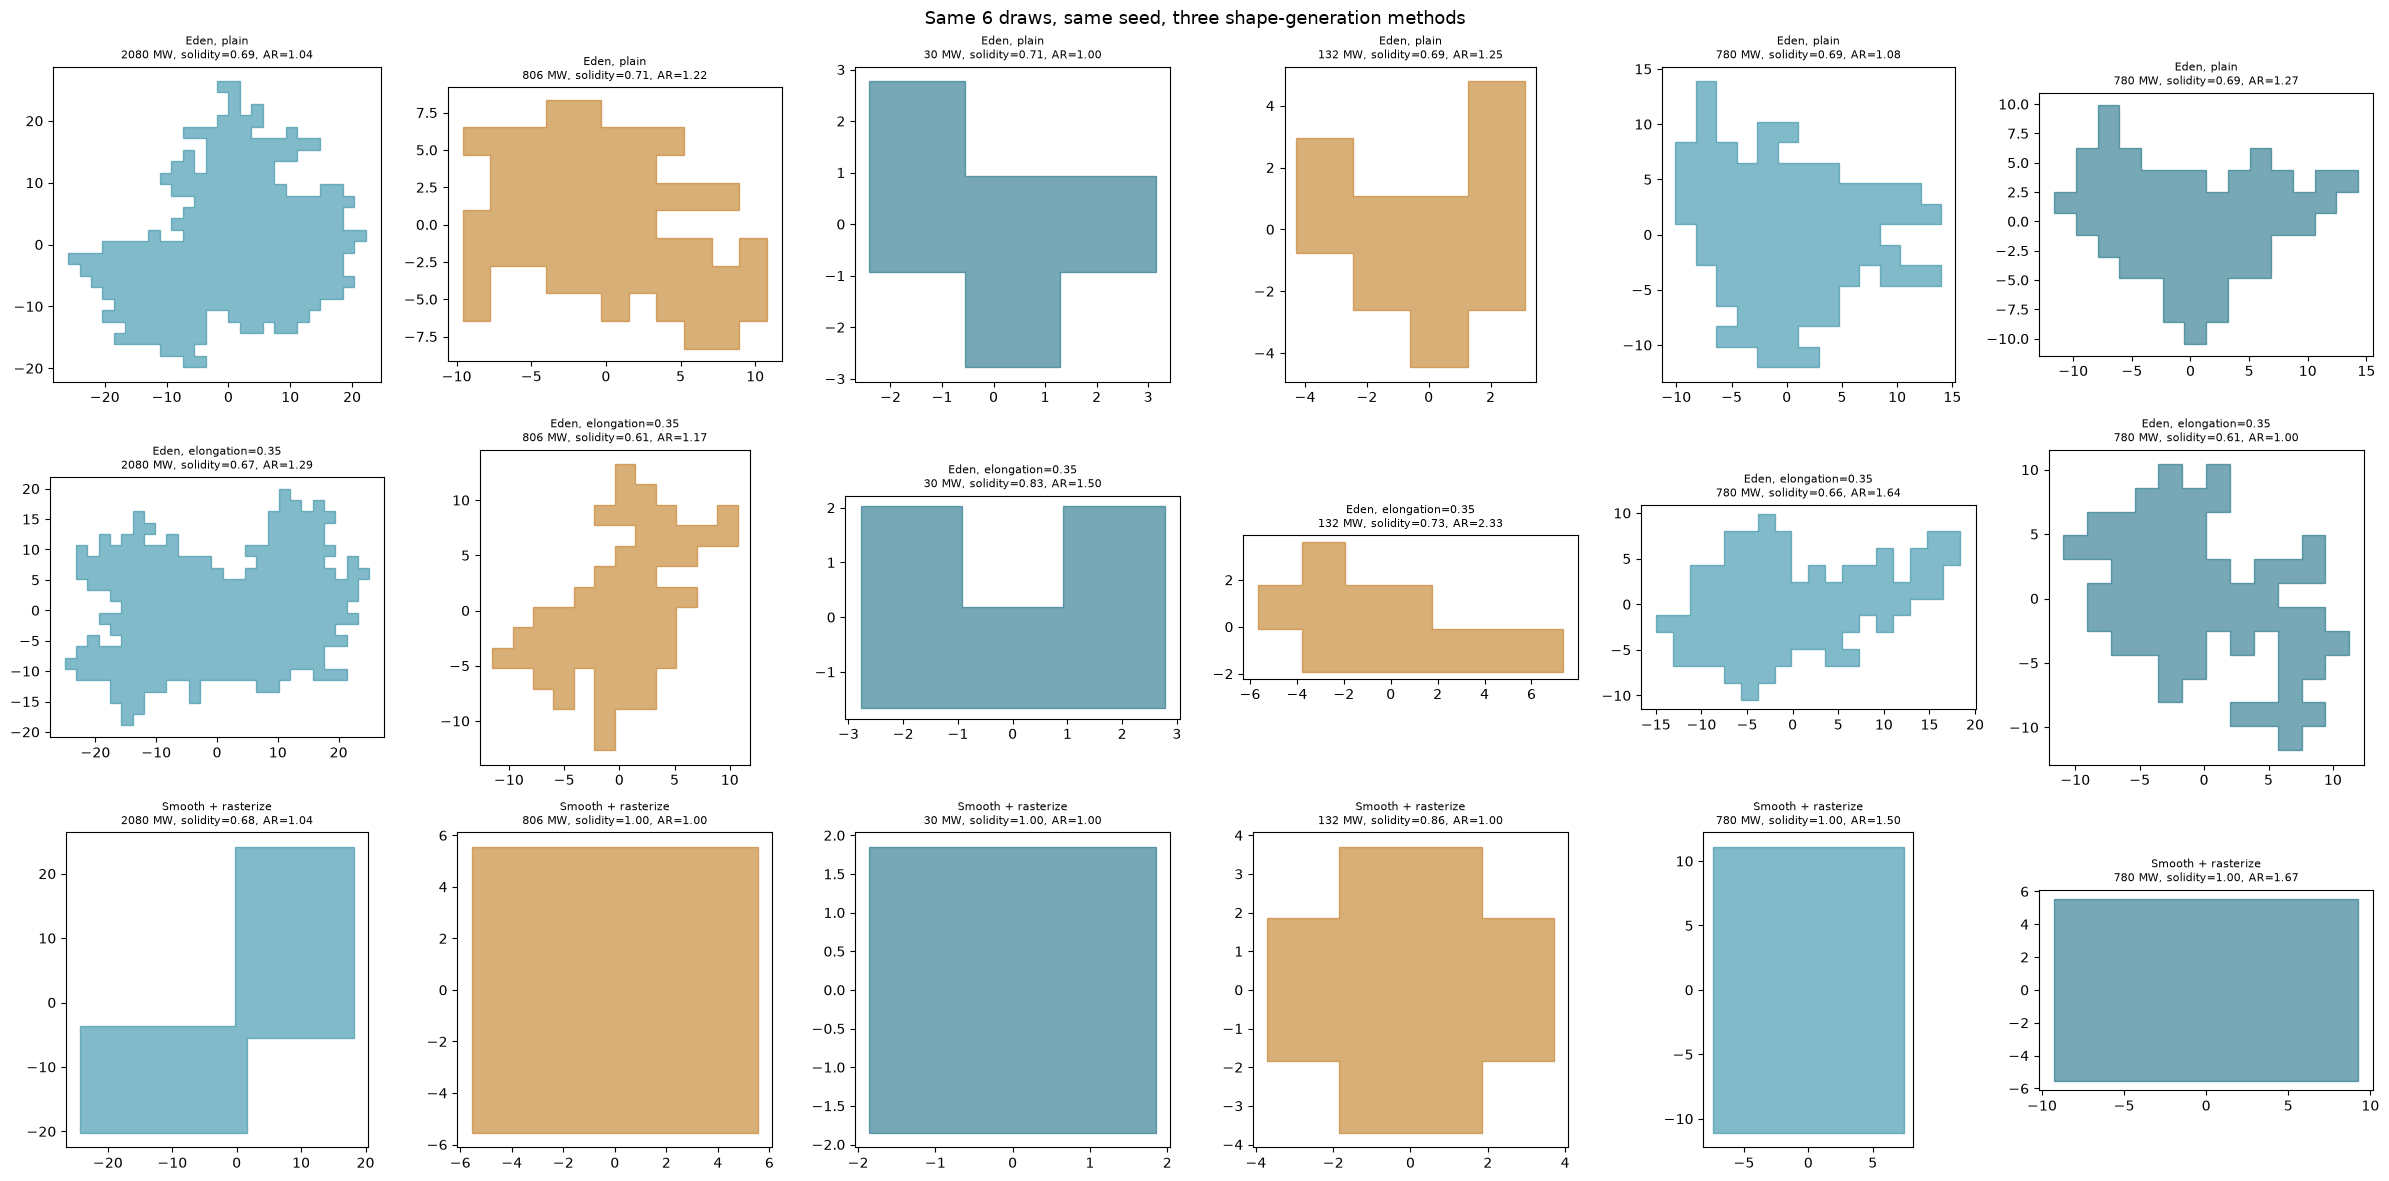

In [10]:
SHOW_IDX = [0, 1, 2, 4, 7, 10]  # spans the capacity range drawn in Section 4

fig, axes = plt.subplots(3, len(SHOW_IDX), figsize=(4 * len(SHOW_IDX), 12))
for row, (label, results) in enumerate([
    ("Eden, plain", results_eden_plain),
    (f"Eden, elongation={DEFAULT_ELONGATION}", results_eden_elong),
    ("Smooth + rasterize", results_staircase),
]):
    for col, idx in enumerate(SHOW_IDX):
        d = results[idx]
        ax = axes[row, col]
        x, y = d["shape"].exterior.xy
        x0, y0 = d["shape"].centroid.x, d["shape"].centroid.y
        ax.fill((np.array(x) - x0) / 1000, (np.array(y) - y0) / 1000, color=COLORS[d["turbine"]], alpha=0.6)
        ax.set_title(f"{label}\n{d['capacity_mw']:.0f} MW, solidity={d['solidity']:.2f}, AR={d['aspect']:.2f}", fontsize=8)
        ax.set_aspect("equal")

fig.suptitle("Same 6 draws, same seed, three shape-generation methods", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "staircase_shape_test_three_methods.png", dpi=170, bbox_inches="tight")
plt.show()

## Summary

`grow_staircase_boundary(target_area_km2, rng, theta1_deg)` in `staircase.py` is the function to use going forward. Against the 10 larger real leases it matches on three independent metrics at once: solidity (0.85 vs 0.79 mean -- solid body, not fingered), aspect ratio (1.32 vs 1.28 mean -- appropriately elongated), and staircase run-length (~13.6 vs 12-23 for well-behaved leases -- the edge drifts coherently in one direction instead of backtracking). `grow_eden_boundary` (the original random-walk version, with or without `elongation`) gets area and 0/90 alignment right but fails the other two -- solidity ~0.65-0.68 and run-length ~4.5, matching only Revolution Wind, the most chaotic real example, not the cluster as a whole. All three came from one design change (build a smooth outline, rasterize it, instead of growing cells one at a time) rather than three separate patches. If the shapes in Section 8 look right, the next step is wiring `grow_staircase_boundary` into `generate_farm()` in place of the template-scale-rotate block in `layout_generation.ipynb` -- positioning, SLA/bathymetry/connection filtering, and overlap checking all stay exactly as they are today.